In [1]:
%load_ext autoreload
%autoreload 2

import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

from spatial_tcr.utils import switch_cwd_to_root

switch_cwd_to_root()

import spatialtools as st

figure_dir = "figures/revision/supplement-extra"
st.utils.setup_plotting(figure_dir, display_dpi=200)

import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

Changed working directory to /bonn-epyc/projects/dschaub/analysis-projects/spatial-tcr
Arial font found!


In [2]:
def _sample_sort_key(x: str) -> tuple[int, int]:
    m = re.fullmatch(r"([CS])(\d+)", str(x))
    if not m:
        return (2, 10**12)  # put anything unexpected at the end
    grp, num = m.group(1), int(m.group(2))
    return (0 if grp == "C" else 1, num)

## Analyze batch mixing for all cell types

In [3]:
def plot_counts_stacked(
    df_counts,
    figsize=(16, 6),
    save_path=None,
    title=None,
    expected_cols=None,
    col_name_mapping=None,
    ncols=8,
    colormap="tab20",
    ylabel="Sample",
    legend_bbox_to_anchor=(0.5, -0.05),
):
    # If normalize is True, create stacked bar plot with absolute counts on the right
    expected_cols = df_counts.columns.tolist() or expected_cols
    col_name_mapping = col_name_mapping or {c: c for c in expected_cols}
    # Ensure we have the expected columns
    for col in expected_cols:
        if col not in df_counts.columns:
            raise ValueError(f"Expected column '{col}' not found in df_counts")

    # Normalize each row to sum to 1 for proportions
    df_plot = df_counts[expected_cols].div(df_counts[expected_cols].sum(axis=1), axis=0)

    # Calculate total counts per sample
    total_counts = df_counts[expected_cols].sum(axis=1)

    # Define column names and corresponding labels/colors
    plot_configs = [(col, col_name_mapping[col]) for col in expected_cols]

    # Get samples
    samples = df_plot.index.tolist()
    y_pos = np.arange(len(samples))

    # Create figure with 2 subplots side by side, right axes 20% width of left
    fig, axes = plt.subplots(
        1, 2, figsize=figsize, sharey=True, gridspec_kw={"width_ratios": [5, 1]}
    )
    fig.subplots_adjust(wspace=0.3)

    ax_left = axes[0]
    ax_right = axes[1]

    # Colors for each category
    colors = sns.color_palette(colormap, n_colors=len(plot_configs))

    # Left subplot: stacked horizontal bars (proportions)
    left = np.zeros(len(samples))
    for idx, (col, label) in enumerate(plot_configs):
        values = df_plot[col].values
        ax_left.barh(
            y_pos, values, left=left, align="center", label=label, color=colors[idx]
        )
        left += values

    # Set y-axis ticks and labels
    ax_left.set_yticks(y_pos)
    ax_left.set_yticklabels(samples, fontsize=8)
    ax_left.set_ylabel(ylabel, fontsize=10)
    ax_left.tick_params(axis="x", labelsize=8)

    # Set x-axis label and limits
    ax_left.set_xlabel("Proportion of cells", fontsize=10)
    ax_left.set_xlim(0, 1)

    # Add legend below the plot
    handles, labels = ax_left.get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=legend_bbox_to_anchor,
        ncol=ncols,
        fontsize=10,
        columnspacing=0.6,  # Reduce column spacing (default is 2.0)
    )

    # Add grid for better readability
    ax_left.grid(axis="x", alpha=0.3, linestyle="--")
    sns.despine(top=True, right=True, ax=ax_left)

    # Right subplot: absolute counts
    muted_red = "#c44e52"  # Muted red color
    ax_right.barh(y_pos, total_counts.values, align="center", color=muted_red)
    ax_right.set_yticks(y_pos)
    ax_right.set_yticklabels(samples, fontsize=8)
    ax_right.set_xlabel("Number of cells", fontsize=10)
    ax_right.set_title("Total cells", fontsize=10, fontweight="bold")
    ax_right.grid(axis="x", alpha=0.3, linestyle="--")
    sns.despine(top=True, right=True, ax=ax_right)

    # Add overall title if provided
    if title is not None:
        fig.suptitle(title, fontsize=10, fontweight="bold", y=1.02)

    plt.tight_layout(rect=[0, 0.1, 1, 1])

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, axes

In [4]:
path = "data/xenium/processed/04.1-kidney_tcr_tsub_harmonized.h5ad"
adata = sc.read_h5ad(path)
adata.X = adata.layers["counts"].copy()
adata

AnnData object with n_obs × n_vars = 510139 × 480
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'graph', 'log1p'
    obsm: 'cell_type_no_tcr_probs', 'spatial'
    layers: 'counts', 'log1p'

In [5]:
adata.obs["condition"].value_counts()

condition
ANCA       389390
Control    120749
Name: count, dtype: int64

In [6]:
adata.obs["slide_short"] = adata.obs["slide"].map(
    {s: f"Slide-{i}" for i, s in enumerate(adata.obs["slide"].unique())}
)
control_samples = adata.obs[adata.obs["condition"] == "Control"]["sample"].unique()
samples = list(adata.obs["sample"].unique())

controls = [s for s in samples if s in control_samples]
cases = [s for s in samples if s not in control_samples]

mapping = {s: f"C{i}" for i, s in enumerate(controls)}
mapping.update({s: f"S{i}" for i, s in enumerate(cases)})

adata.obs["sample_short"] = adata.obs["sample"].map(mapping)

# adata.obs["sample_short"] = adata.obs["sample"].map(
#     {
#         s: f"C{i}" if s in control_samples else f"S{i}"
#         for i, s in enumerate(adata.obs["sample"].unique())
#     }
# )
adata.obs["sample_short"].value_counts()

sample_short
C2    59522
S3    51667
S4    49616
S5    48685
S6    43484
S1    43301
S0    40288
S2    38513
C0    35322
S7    33600
C1    25905
S9    25742
S8    14494
Name: count, dtype: int64

/tmp/ipykernel_107435/3803066361.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata.obs.groupby(["sample_short"])["cell_type_l1"].value_counts().unstack()


(<Figure size 1600x800 with 2 Axes>,
 array([<Axes: xlabel='Proportion of cells', ylabel='Sample'>,
        <Axes: title={'center': 'Total cells'}, xlabel='Number of cells'>],
       dtype=object))

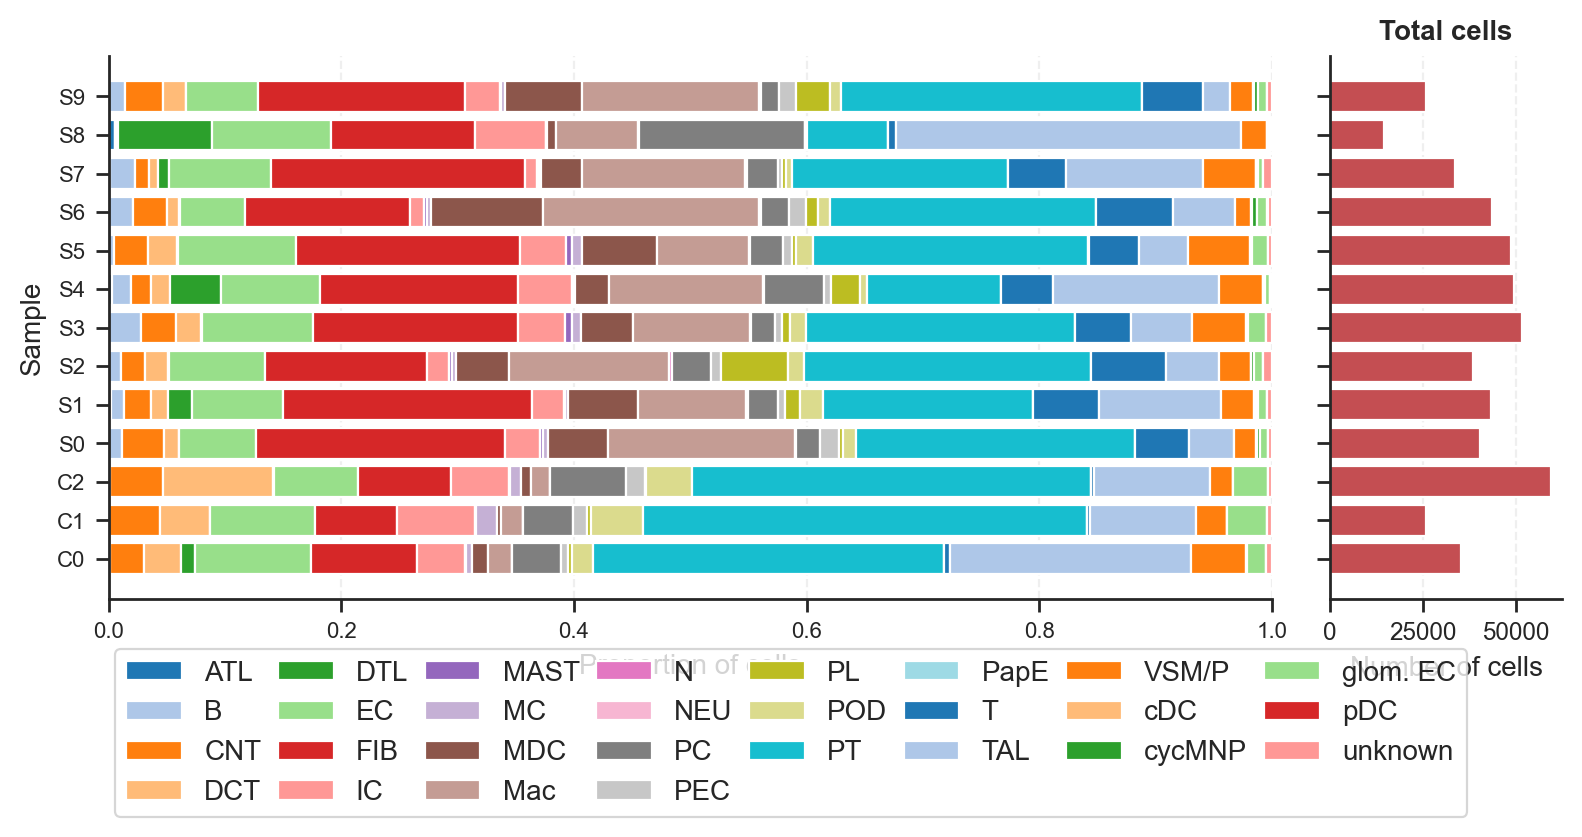

In [7]:
counts = adata.obs.groupby(["sample_short"])["cell_type_l1"].value_counts().unstack()

counts = counts.loc[sorted(counts.index, key=_sample_sort_key)]
plot_counts_stacked(
    counts,
    colormap="tab20",
    figsize=(8, 4),
    save_path=f"{figure_dir}/cell_type_props_sample.pdf",
)

/tmp/ipykernel_107435/2854303211.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata.obs.groupby(["slide_short"])["cell_type_l1"].value_counts().unstack()


(<Figure size 3200x400 with 2 Axes>,
 array([<Axes: xlabel='Proportion of cells', ylabel='Slide'>,
        <Axes: title={'center': 'Total cells'}, xlabel='Number of cells'>],
       dtype=object))

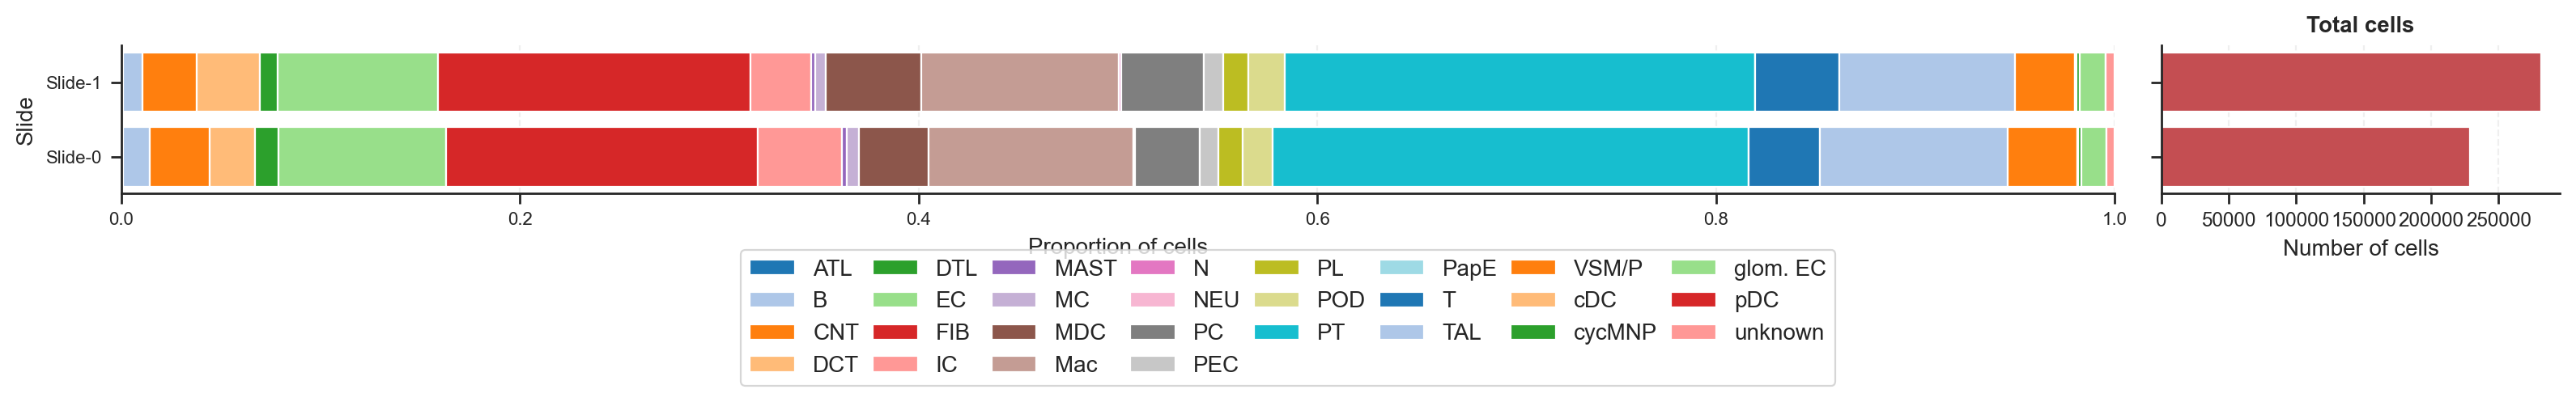

In [8]:
counts = adata.obs.groupby(["slide_short"])["cell_type_l1"].value_counts().unstack()

counts = counts.loc[sorted(counts.index, key=_sample_sort_key)]
plot_counts_stacked(
    counts,
    figsize=(16, 2),
    legend_bbox_to_anchor=(0.5, -0.25),
    ylabel="Slide",
)

## Analyze batch mixing for tcell subtypes

In [9]:
ad_t = adata[adata.obs["cell_type_l1"] == "T"].copy()

/tmp/ipykernel_107435/3958338169.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = ad_t.obs.groupby(["sample_short"])["cell_type_l2"].value_counts().unstack()


(<Figure size 1600x800 with 2 Axes>,
 array([<Axes: xlabel='Proportion of cells', ylabel='Sample'>,
        <Axes: title={'center': 'Total cells'}, xlabel='Number of cells'>],
       dtype=object))

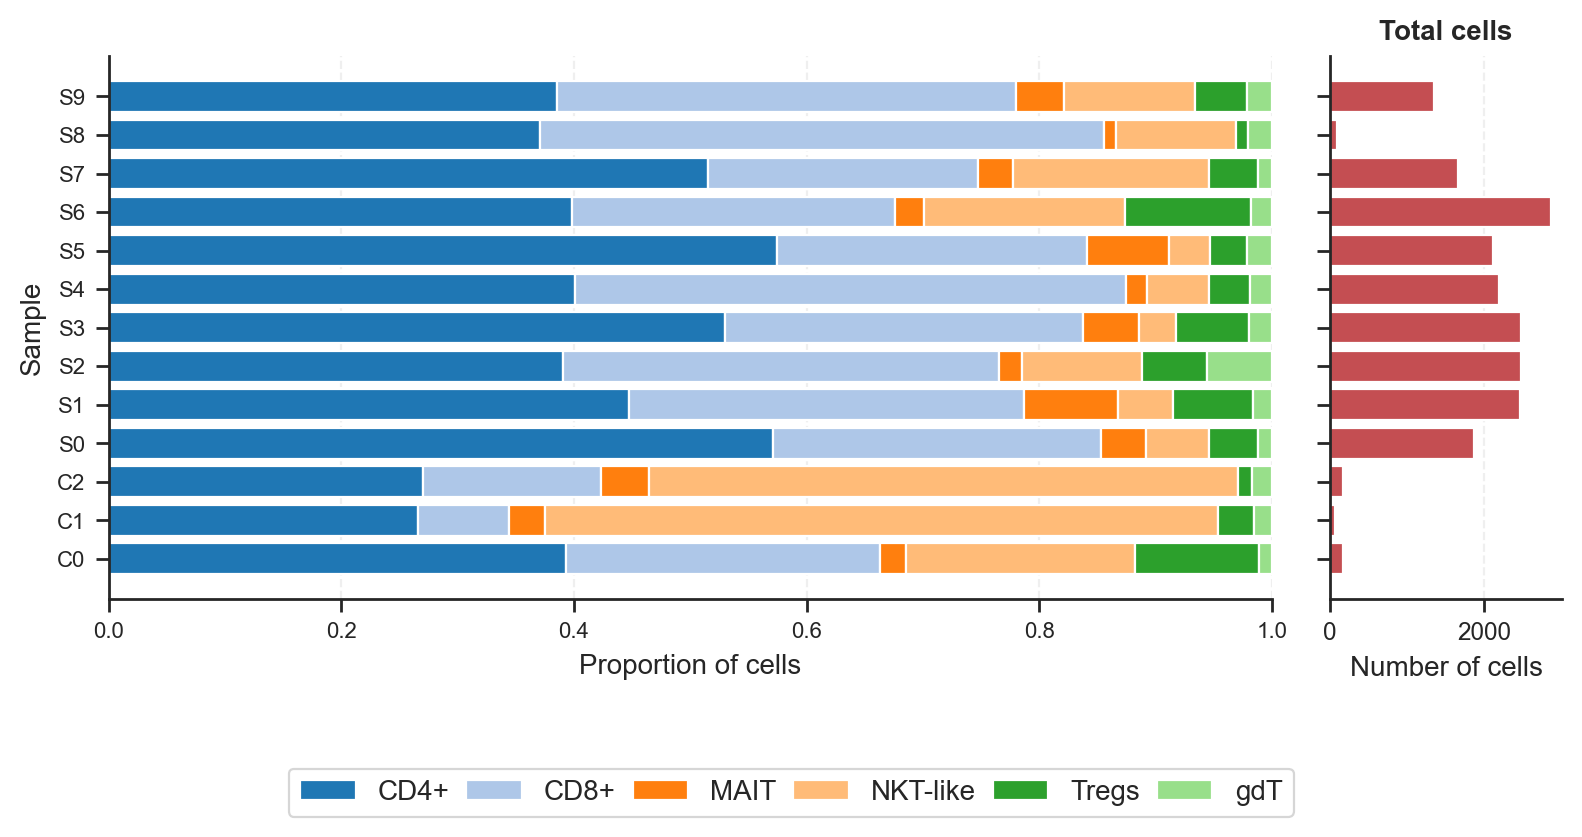

In [10]:
counts = ad_t.obs.groupby(["sample_short"])["cell_type_l2"].value_counts().unstack()

counts = counts.loc[sorted(counts.index, key=_sample_sort_key)]
plot_counts_stacked(
    counts,
    # legend_bbox_to_anchor=(0.5, 0.03),
    ylabel="Sample",
    figsize=(8, 4),
    save_path=f"{figure_dir}/tcell_subtype_props_sample.pdf",
)

/tmp/ipykernel_107435/3235770113.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = ad_t.obs.groupby(["slide_short"])["cell_type_l2"].value_counts().unstack()


(<Figure size 3200x400 with 2 Axes>,
 array([<Axes: xlabel='Proportion of cells', ylabel='Slide'>,
        <Axes: title={'center': 'Total cells'}, xlabel='Number of cells'>],
       dtype=object))

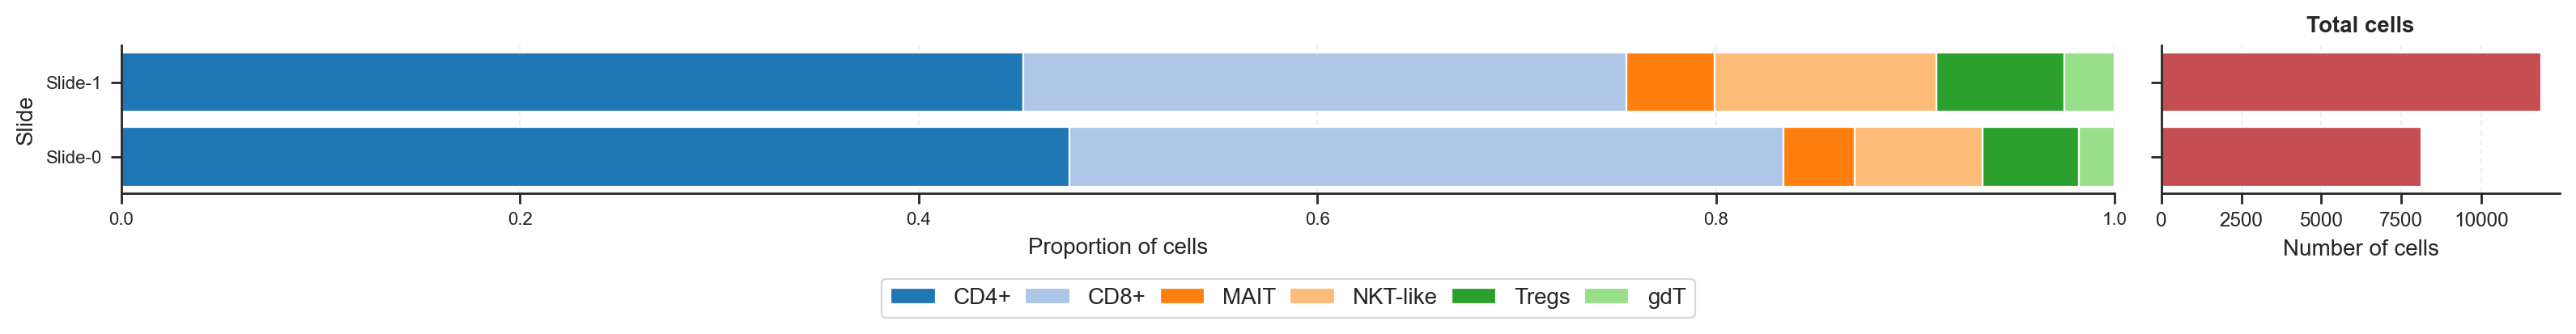

In [11]:
counts = ad_t.obs.groupby(["slide_short"])["cell_type_l2"].value_counts().unstack()

counts = counts.loc[sorted(counts.index, key=_sample_sort_key)]
plot_counts_stacked(
    counts, figsize=(16, 2), legend_bbox_to_anchor=(0.5, -0.04), ylabel="Slide"
)

## Compare mixing with with and without Harmony integration for subtypes

In [12]:
import scanpy.external as sce

In [13]:
ad_t.X = ad_t.layers["counts"].copy()
sc.pp.normalize_total(ad_t)
sc.pp.log1p(ad_t)
sc.pp.highly_variable_genes(ad_t, n_top_genes=100, batch_key="sample")

In [14]:
markers_flattend = []
reduced_var_names = ad_t.var_names[ad_t.var["highly_variable"]].tolist()
reduced_var_names = [
    v for v in reduced_var_names if v not in markers_flattend
] + markers_flattend
ad_t = ad_t[:, reduced_var_names].copy()
ad_t

AnnData object with n_obs × n_vars = 20013 × 100
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'slide_short', 'sample_short'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'graph', 'log1p', 'hvg'
    obsm: 'cell_type_no_tcr_probs', 'spatial'
    layers: 'counts', 'log1p'

In [15]:
ad_t.X = ad_t.layers["counts"].copy()
sc.pp.normalize_total(ad_t)
sc.pp.log1p(ad_t)
sc.tl.pca(ad_t, n_comps=50)

In [16]:
sce.pp.harmony_integrate(
    ad_t, "sample", adjusted_basis="X_pca_harmony_sample", max_iter_harmony=20
)
sc.pp.neighbors(ad_t, use_rep="X_pca_harmony_sample")
sc.tl.leiden(ad_t, resolution=1.0, key_added="leiden_harmony_sample")
ad_t.obs["leiden_harmony_sample"].value_counts()

2026-04-14 12:52:56,848 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-04-14 12:53:00,142 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-04-14 12:53:00,206 - harmonypy - INFO - Iteration 1 of 20
2026-04-14 12:53:03,435 - harmonypy - INFO - Iteration 2 of 20
2026-04-14 12:53:06,674 - harmonypy - INFO - Iteration 3 of 20
2026-04-14 12:53:08,988 - harmonypy - INFO - Iteration 4 of 20
2026-04-14 12:53:10,775 - harmonypy - INFO - Iteration 5 of 20
2026-04-14 12:53:12,305 - harmonypy - INFO - Iteration 6 of 20
2026-04-14 12:53:13,701 - harmonypy - INFO - Iteration 7 of 20
2026-04-14 12:53:15,102 - harmonypy - INFO - Iteration 8 of 20
2026-04-14 12:53:16,372 - harmonypy - INFO - Iteration 9 of 20
2026-04-14 12:53:17,771 - harmonypy - INFO - Iteration 10 of 20
2026-04-14 12:53:19,158 - harmonypy - INFO - Iteration 11 of 20
2026-04-14 12:53:20,418 - harmonypy - INFO - Iteration 12 of 20
2026-04-14 12:53:21,687 - harmonypy - INFO - Iteration 13 of

leiden_harmony_sample
0     2735
1     2395
2     2345
3     2299
4     2260
5     2025
6     1790
7     1416
8     1025
9      937
10     347
11     297
12     142
Name: count, dtype: int64

In [17]:
sce.pp.harmony_integrate(ad_t, "slide", adjusted_basis="X_pca_harmony_slide")
sc.pp.neighbors(ad_t, use_rep="X_pca_harmony_slide")
sc.tl.leiden(ad_t, resolution=1.0, key_added="leiden_harmony_slide")
ad_t.obs["leiden_harmony_slide"].value_counts()

2026-04-14 12:54:29,928 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-04-14 12:54:33,170 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-04-14 12:54:33,232 - harmonypy - INFO - Iteration 1 of 10
2026-04-14 12:54:36,019 - harmonypy - INFO - Iteration 2 of 10
2026-04-14 12:54:38,795 - harmonypy - INFO - Iteration 3 of 10
2026-04-14 12:54:40,586 - harmonypy - INFO - Converged after 3 iterations


leiden_harmony_slide
0     3090
1     2896
2     2669
3     2628
4     2518
5     2158
6     2145
7      942
8      518
9      289
10     160
Name: count, dtype: int64

In [18]:
ad_t.obsm["X_pca_sample"] = ad_t.obsm["X_pca"].copy()
ad_t.obsm["X_pca_slide"] = ad_t.obsm["X_pca"].copy()

In [ ]:
from scib_metrics.benchmark import Benchmarker

batch_key = ["sample", "slide", "sample", "slide"]
embed_keys = [
    "X_pca_sample",
    "X_pca_slide",
    "X_pca_harmony_sample",
    "X_pca_harmony_slide",
]
label_keys = [
    "cell_type_l2",
    "cell_type_l2",
    "leiden_harmony_sample",
    "leiden_harmony_slide",
]
all_results = []
for bk, ek, lk in zip(batch_key, embed_keys, label_keys):
    bm = Benchmarker(
        ad_t,
        batch_key=bk,
        label_key=lk,  # or "leiden" / your cluster column
        embedding_obsm_keys=[ek],
    )
    bm.benchmark()
    results = bm.get_results()
    all_results.append(results)
    display(results)
    # break
all_results = pd.concat(all_results, axis=0)
all_results

/home/dschaub/.uv-local/venvs/spatial-tcr/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
Embeddings:   0%|          | 0/1 [00:00<?, ?it/s]WARNING:2026-04-14 12:55:12,066:jax._src.xla_bridge:876: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.

Metrics:  10%|█         | 1/10 [00:16<02:32, 16.92s/it, Bio conservation: isolated_labels]

In [ ]:
metrics = all_results[~all_results.index.str.contains("Metric")]
metrics = metrics.reset_index()
metrics.to_csv("data/xenium/processed/09-batch_mixing_metrics.csv", index=False)

In [ ]:
metrics = pd.read_csv("data/xenium/processed/09-batch_mixing_metrics.csv")
metrics

,Embedding,Isolated labels,KMeans NMI,KMeans ARI,Silhouette label,cLISI,BRAS,iLISI,KBET,Graph connectivity,PCR comparison,Batch correction,Bio conservation,Total
0,X_pca_sample,0.526004,0.258277,0.179361,0.511815,0.938263,0.948594,0.290948,0.579467,0.889469,0.000000,0.541695,0.482744,0.506325
1,X_pca_slide,0.526004,0.258277,0.179361,0.511815,0.938263,0.967163,0.780781,0.691525,0.889469,0.000000,0.665788,0.482744,0.555962
2,X_pca_harmony_sample,0.552503,0.403217,0.318663,0.515935,0.937390,0.972510,0.351622,0.882690,0.876033,0.874281,0.791427,0.545542,0.643896
3,X_pca_harmony_slide,0.519907,0.399909,0.317045,0.515869,0.919518,0.987648,0.832105,0.921989,0.900875,0.936147,0.915753,0.534450,0.686971


In [ ]:
metrics[["Embedding"]]

,Embedding
0,X_pca_sample
1,X_pca_slide
2,X_pca_harmony_sample
3,X_pca_harmony_slide


## Plot comparison

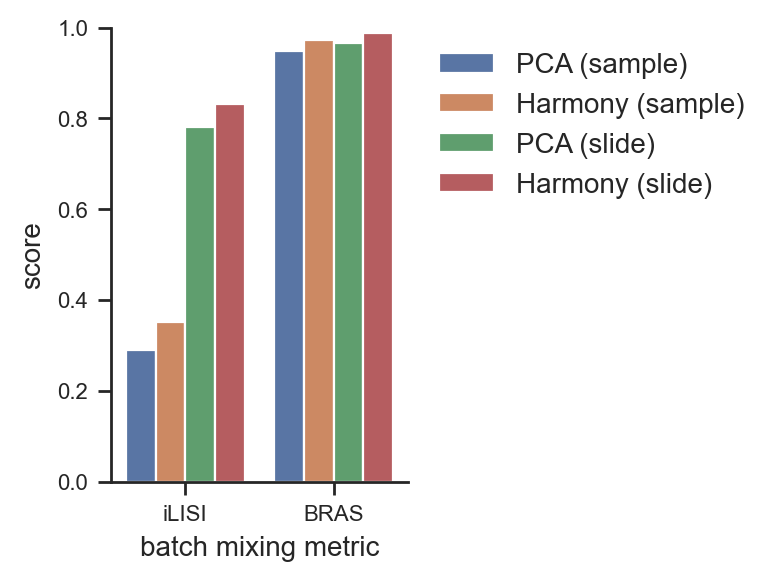

In [ ]:
# pick the three embeddings you want
embeddings = [
    "X_pca_sample",
    "X_pca_harmony_sample",
    "X_pca_slide",
    "X_pca_harmony_slide",
]

# mapping for cleaner legend names
embedding_names = {
    "X_pca_sample": "PCA (sample)",
    "X_pca_slide": "PCA (slide)",
    "X_pca_harmony_sample": "Harmony (sample)",
    "X_pca_harmony_slide": "Harmony (slide)",
}

# keep only iLISI + cLISI and reshape so x-axis = metric, hue = embedding
df = (
    metrics.loc[metrics["Embedding"].isin(embeddings), ["Embedding", "iLISI", "BRAS"]]
    .drop_duplicates("Embedding")
    .melt(id_vars="Embedding", var_name="Metric", value_name="Score")
)

fig, ax = plt.subplots(figsize=(4, 3))
ax = sns.barplot(
    data=df,
    x="Metric",
    y="Score",
    hue="Embedding",
    order=["iLISI", "BRAS"],  # optional: control x-axis order
    hue_order=embeddings,  # optional: control legend/bar order
    errorbar=None,
    ax=ax,
)

ax.set_ylim(0, 1)
ax.set_xlabel("batch mixing metric", fontsize=10)
ax.set_ylabel("score", fontsize=10)
legend = ax.legend(
    title="",
    frameon=False,
    ncol=1,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=10,
)
ax.tick_params(axis="both", labelsize=8)

# update legend labels with cleaner names
for t in legend.get_texts():
    t.set_text(embedding_names.get(t.get_text(), t.get_text()))
sns.despine()
plt.tight_layout()
plt.savefig(
    f"{figure_dir}/batch_mixing_metrics.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()